In [3]:
import pandas as pd
import numpy as np
data={
    "weather":['sunny','sunny','cloudy','rainy','rainy','rainy','cloudy','suuny','sunny','rainy','sunny','cloudy','cloudy','rainy'],
    "temperature":['hot','hot','hot','mild','cool','cool','cool','mild','cool','mild','mild','mild','hot','mild'],
    "soil moisture":['dry','dry','dry','dry','moist','moist','moist','dry','moist','moist','moist','dry','moist','dry'],
    "wind":['weak','strong','weak','weak','weak','strong','strong','weak','weak','weak','strong','strong','weak','strong'],
    "irrigate":['no','no','yes','yes','yes','no','yes','no','yes','yes','yes','yes','yes','no']
}
df=pd.DataFrame(data)
print(df)


#step1:entropy
def entropy(target):
  values,counts=np.unique(target,return_counts=True)
  prob=counts/counts.sum()
  return-np.sum(prob*np.log2(prob))

#step2:information gain
def information_gain(data,feature,target_name):
  total_entropy=entropy(data[target_name])
  values,counts=np.unique(data[feature],return_counts=True)
  weighted_entropy=0
  for i in range(len(values)):
    subset=data[data[feature]==values[i]]
    weighted_entropy+=(counts[i]/np.sum(counts))*entropy(subset[target_name])
    return total_entropy-weighted_entropy

#step3:ID3 algorithm
def id3(data,features,target_name,depth=0):
  indent="  "*depth
  if len(np.unique(data[target_name]))==1:
     return np.unique(data[target_name])[0]
  if len(features)==0:
      return data[target_name].mode()[0]

  gains=[]
  print(f"\n{indent}Evaluating features at depth {depth}:")
  for feature in features:
    gain=information_gain(data,feature,target_name)
    gains.append(gain)
    print(f"{indent}|G({feature})={gain:.4f}")
  best_feature=features[np.argmax(gains)]
  print(f"{indent}Best Feature --> {best_feature}")

  tree={best_feature:{}}

  for value in np.unique(data[best_feature]):
    print(f"{indent}splitting {best_feature}={value}")
    subset=data[data[best_feature]==value]
    if subset.shape[0]==0:
       tree[best_feature][value]=data[target_name].mode()[0]
    else:
      remaining_features=[f for f in features if f!=best_feature]
      subtree=id3(subset,remaining_features,target_name,depth+1)
      tree[best_feature][value]=subtree
  return tree


def print_tree(tree,indent=""):
  if not isinstance (tree,dict):
    print(indent+"",(tree))
    return
  for feature,branches in tree.items():
    for value ,subtree in branches.items():
      print(f"{indent}{feature}={value}:")
      print_tree(subtree,indent +"  ")

features=list(df.columns[:-1])
tree_model=id3(df,features,'irrigate')

print("\nFinal Decision Tree:\n")
print_tree(tree_model)



   weather temperature soil moisture    wind irrigate
0    sunny         hot           dry    weak       no
1    sunny         hot           dry  strong       no
2   cloudy         hot           dry    weak      yes
3    rainy        mild           dry    weak      yes
4    rainy        cool         moist    weak      yes
5    rainy        cool         moist  strong       no
6   cloudy        cool         moist  strong      yes
7    suuny        mild           dry    weak       no
8    sunny        cool         moist    weak      yes
9    rainy        mild         moist    weak      yes
10   sunny        mild         moist  strong      yes
11  cloudy        mild           dry  strong      yes
12  cloudy         hot         moist    weak      yes
13   rainy        mild           dry  strong       no

Evaluating features at depth 0:
|G(weather)=0.9403
|G(temperature)=0.7085
|G(soil moisture)=0.4477
|G(wind)=0.5117
Best Feature --> weather
splitting weather=cloudy
splitting weather=rainy


sample dataset;
   weather   Soil temperature humidity    wind fertilizer crop Type  season  \
0   Rainy  moist        high     high    weak        yes      corn    rabi   
1   sunny    dry         low      low    weak        yes      rice    rabi   
2   Rainy  moist      medium   medium  strong        yes      rice  kharif   
3   Rainy  moist         low     high  strong        yes      rice  kharif   
4   sunny  moist         low     high    weak         no      rice  kharif   

  irrigate  
0       no  
1      yes  
2       no  
3       no  
4      yes  

Accuracy Comparison:
Decision Tree Accuracy: 0.9444444444444444
Random Forest Accuracy: 0.9444444444444444

Decision Tree Confusion Matrix:
             Pred No  Pred Yes
Actual NO         8         0
Actual Yes        1         9

Random Forest Confusion Matrix:
             Pred No  Pred Yes
Actual No         7         1
Actual Yes        2         8


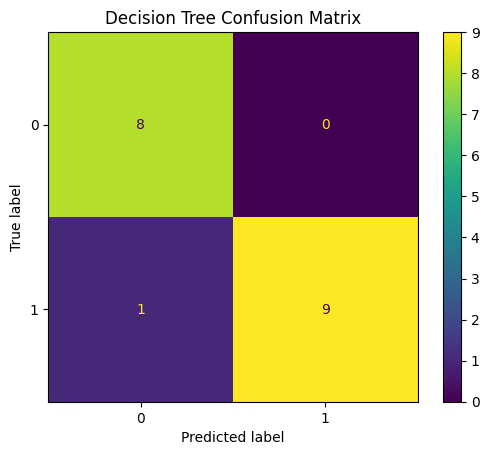


Cross Validation Accuracy
Decision Tree: 0.8333333333333334
Random Forest: 0.8333333333333334

Feature Importance:
        Feature  Importance
1         Soil    0.397597
6    crop Type    0.126547
5   fertilizer    0.114531
2  temperature    0.099303
0      weather    0.090000
7       season    0.068874
3     humidity    0.064978
4         wind    0.038170


In [6]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

#generate Larger farming dataset
np.random.seed(42)
n_samples=60
data={
    'weather':np.random.choice(['sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['dry','moist','wet'],n_samples),
    'temperature':np.random.choice(['high','medium','low'],n_samples),
    'humidity':np.random.choice(['high','medium','low'],n_samples),
    'wind':np.random.choice(['strong','weak'],n_samples),
    'fertilizer':np.random.choice(['yes','no'],n_samples),
    'crop Type':np.random.choice(['wheat','rice','corn'],n_samples),
    'season':np.random.choice(['kharif','rabi','summer'],n_samples)
    }
df=pd.DataFrame(data)

#3.create target variable

def irrigation_rule(row):
  if row['Soil']=='dry'and row['weather']!='rainy':
    return 'yes'
  elif row['Soil']=='wet':
    return 'no'
  elif row['humidity']=='high'and row['weather']=='rainy':
    return 'no'
  else:
    return np.random.choice(['yes','no'])
df['irrigate']=df.apply(irrigation_rule,axis=1)
print("sample dataset;\n",df.head())

#4.encode categorical variables
le_dict={}
for column in df.columns:
  le=LabelEncoder()
  df[column]=le.fit_transform(df[column])
  le_dict[column]=le


#5.split features and target
x=df.drop('irrigate',axis=1)
y=df['irrigate']

#6.Train_test split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.3,random_state=42,stratify=y

)

#7.decision tree model
dt_model=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(x_train,y_train)

y_pred_dt=dt_model.predict(x_test)


#8.random forest model
rf_model=RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    random_state=42
)
rf_model.fit(x_train,y_train)
y_pred_rf=rf_model.predict(x_test)

#9.Accuracy evaluation
dt_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_dt)
print("\nAccuracy Comparison:")
print("Decision Tree Accuracy:",dt_accuracy)
print("Random Forest Accuracy:",rf_accuracy)

#10.confusion matrix
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])
cm_dt_df=pd.DataFrame(cm_dt,index=['Actual NO','Actual Yes'],columns=['Pred No','Pred Yes'])
cm_rf_df=pd.DataFrame(cm_rf,index=['Actual No','Actual Yes'],columns=['Pred No','Pred Yes'])
print("\nDecision Tree Confusion Matrix:\n",cm_dt_df)
print("\nRandom Forest Confusion Matrix:\n",cm_rf_df)


#11.Confusion Matrix visualization
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()

#12.Cross validation
dt_cv=cross_val_score(dt_model,x,y,cv=5)
rf_cv=cross_val_score(rf_model,x,y,cv=5)

print("\nCross Validation Accuracy")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())


importance=pd.DataFrame({
    'Feature':x.columns,
    'Importance':rf_model.feature_importances_
}).sort_values(by='Importance',ascending=False)

print("\nFeature Importance:\n",importance)








Accuracy Comparision
Decision Tree Accuracy: 0.6666666666666666
Random Forest Accuracy: 0.7111111111111111

Decision Tree Confusion Matrix: [[31 14]
 [16 29]]

Random forest Confusion Matrix: [[30 15]
 [11 34]]


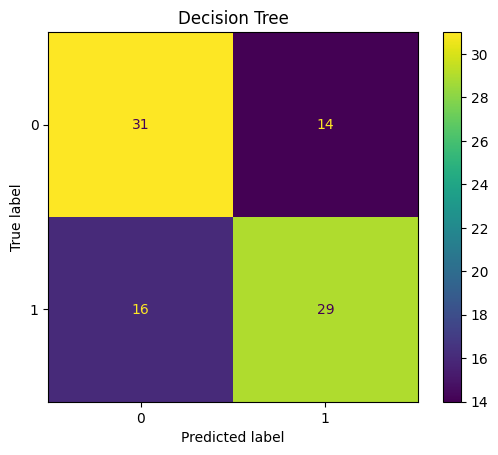

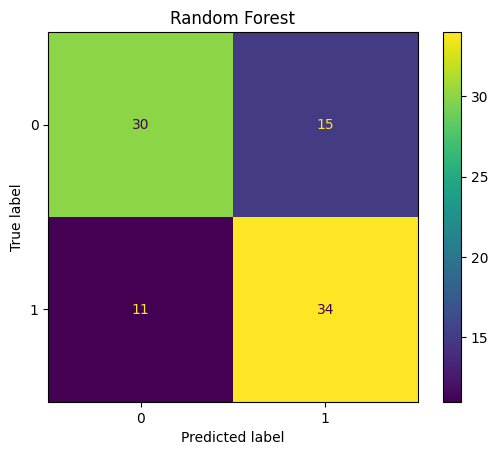


 Cross Validatio
Decision Tree: 0.5633333333333332
Random Forest: 0.6633333333333333


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
np.random.seed(42)

n_samples=300

data={
    'Weather':np.random.choice(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['Dry','Moist','Wet'],n_samples),
    'Temperature':np.random.choice(['Hot','Mild','Cool'],n_samples),
    'Humidity':np.random.choice(['High','Medium','Low'],n_samples),
    'Wind':np.random.choice(['Strong','Weak'],n_samples),
    'Fertilizer':np.random.choice(['Yes','No'],n_samples),
    'Crop Type':np.random.choice(['Wheat','Rice','Corn'],n_samples),
    'Season':np.random.choice(['Kharif','Rabi','Summer'],n_samples)
}
df=pd.DataFrame(data)

def irrigate_rule(row):
  if row['Soil']=='Dry'and row["Weather"]!='Rainy':
    base='Yes'
  elif row['Soil']=='Wet':
    base='No'
  else:
    base=random.choice(['Yes','No'])
  if random.random()<0.2:
    return 'No' if base =='Yes' else 'Yes'
  return base


df['irrigate']=df.apply(irrigate_rule,axis=1)

le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

X=df.drop('irrigate',axis=1)
y=df['irrigate']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)


dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

rf_model=RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)
rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)


dt_acc=accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\nAccuracy Comparision")
print("Decision Tree Accuracy:",dt_acc)
print("Random Forest Accuracy:",rf_acc)


cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])
print("\nDecision Tree Confusion Matrix:",cm_dt)
print("\nRandom forest Confusion Matrix:",cm_rf)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title("Decision Tree")
plt.show()
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title("Random Forest")
plt.show()

dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n Cross Validatio")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())